Partie 2 : Votre Premier Projet de Machine Learning de A à Z

 Étape 1 : Exploration et Compréhension des Données (EDA)

In [121]:
#Libraries import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score



sns.set(style="whitegrid")
%matplotlib inline 

# Load the dataset
df = pd.read_csv('train_u6lujuX_CVtuZ9i (1).csv')

# Display first 5 rows to understand structure
print(df.head())

# Check dataset dimensions
print(f"\nDataset shape: {df.shape}")

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

Relevant features: Applicant Income + Co Applicant Income / Loan Amount Term / Credit History

In [122]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [123]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [124]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Observations

Nombre de lignes : 614 / Colonnes : 13

Types de données : cohérents globalement avec variables catégorielles en object, quantitatives en int ou float.

Plusieurs colonnes avec des NaN : 
Gender
Married	
Dependents
Self_Employed
LoanAmount
Loan_Amount_Term
et surtout Credit_History (50 valeurs manquantes), élément clé pour l'octroi de prêts

Types de données cohérents, sauf pour Dependents (object) : contient sans doute la valeur '3+' → à convertir en numérique.


In [126]:
# 2. Traitement de 'Dependents' : remplacement de '3+' par 3 et conversion en float
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

In [127]:
df['Dependents'].value_counts()

Dependents
0.0    345
1.0    102
2.0    101
3.0     51
Name: count, dtype: int64

In [128]:
# 3. Imputation des valeurs manquantes
# Catégorielles : remplissage par le mode
for col in ['Gender', 'Married', 'Self_Employed', 'Dependents']:
   df[col] = df[col].fillna(df[col].mode()[0])

In [129]:
# 4. Numériques : remplissage par la médiane
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col] = df[col].fillna(df[col].median())

In [130]:
# 5. Encodage des variables catégorielles (hors target)
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols)

In [131]:
# 6. Encodage de la variable cible 'Loan_Status'
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [132]:
print(df.isnull().sum())

Loan_ID                    0
Dependents                 0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Gender_Female              0
Gender_Male                0
Married_No                 0
Married_Yes                0
Education_Graduate         0
Education_Not Graduate     0
Self_Employed_No           0
Self_Employed_Yes          0
Property_Area_Rural        0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64


In [133]:
X = df.drop(columns=['Loan_ID', 'Loan_Status'], errors='ignore')
X = X.astype(int)

In [134]:
X = X.astype(int)

In [135]:
# 1. On enlève les colonnes inutiles
X = df.drop(columns=['Loan_ID', 'Loan_Status'])

# 2. On transforme les variables catégorielles en variables numériques (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# 3. On convertit tout en int (pour éviter les types bool ou float inutiles)
X = X.astype(int)

# 4. Target variable
y = df['Loan_Status']

In [136]:
print(X.dtypes)

Dependents                 int64
ApplicantIncome            int64
CoapplicantIncome          int64
LoanAmount                 int64
Loan_Amount_Term           int64
Credit_History             int64
Gender_Female              int64
Gender_Male                int64
Married_No                 int64
Married_Yes                int64
Education_Graduate         int64
Education_Not Graduate     int64
Self_Employed_No           int64
Self_Employed_Yes          int64
Property_Area_Rural        int64
Property_Area_Semiurban    int64
Property_Area_Urban        int64
dtype: object


In [137]:
# Vérification finale
print(" Nettoyage terminé !")
print(df.info())
print(df.head())

 Nettoyage terminé !
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Dependents               614 non-null    float64
 2   ApplicantIncome          614 non-null    int64  
 3   CoapplicantIncome        614 non-null    float64
 4   LoanAmount               614 non-null    float64
 5   Loan_Amount_Term         614 non-null    float64
 6   Credit_History           614 non-null    float64
 7   Loan_Status              614 non-null    int64  
 8   Gender_Female            614 non-null    bool   
 9   Gender_Male              614 non-null    bool   
 10  Married_No               614 non-null    bool   
 11  Married_Yes              614 non-null    bool   
 12  Education_Graduate       614 non-null    bool   
 13  Education_Not Graduate   614 non-null    bool   
 14  Self_

1. Histogrammes des variables numériques

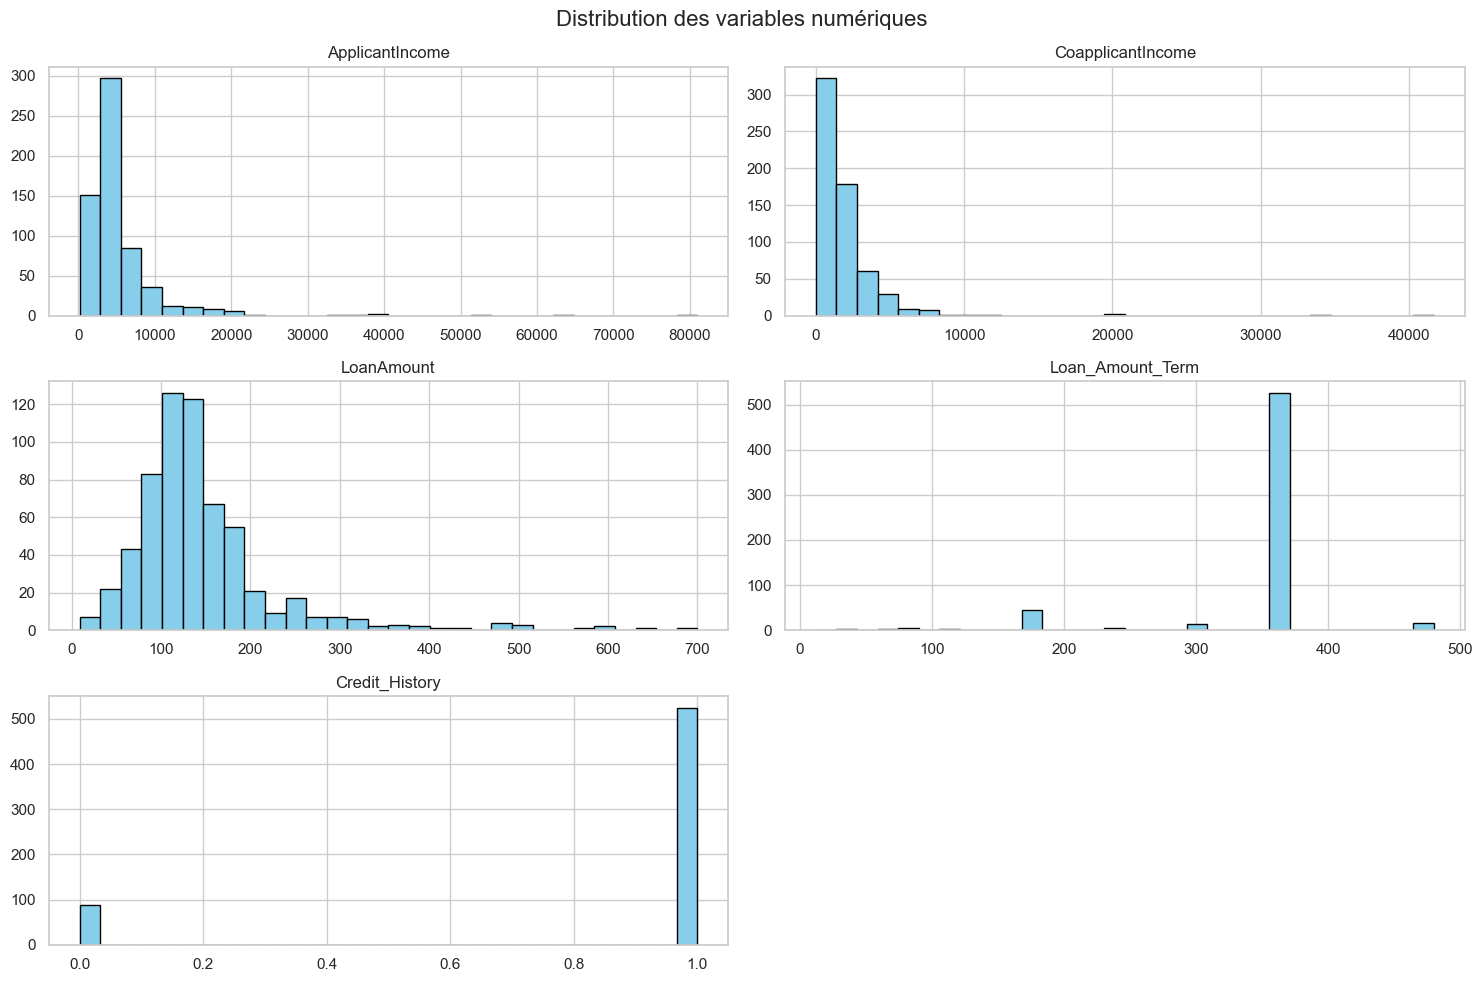

In [138]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

df[numerical_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution des variables numériques', fontsize=16)
plt.tight_layout()
plt.show()

 2. Boxplots pour détecter les outliers

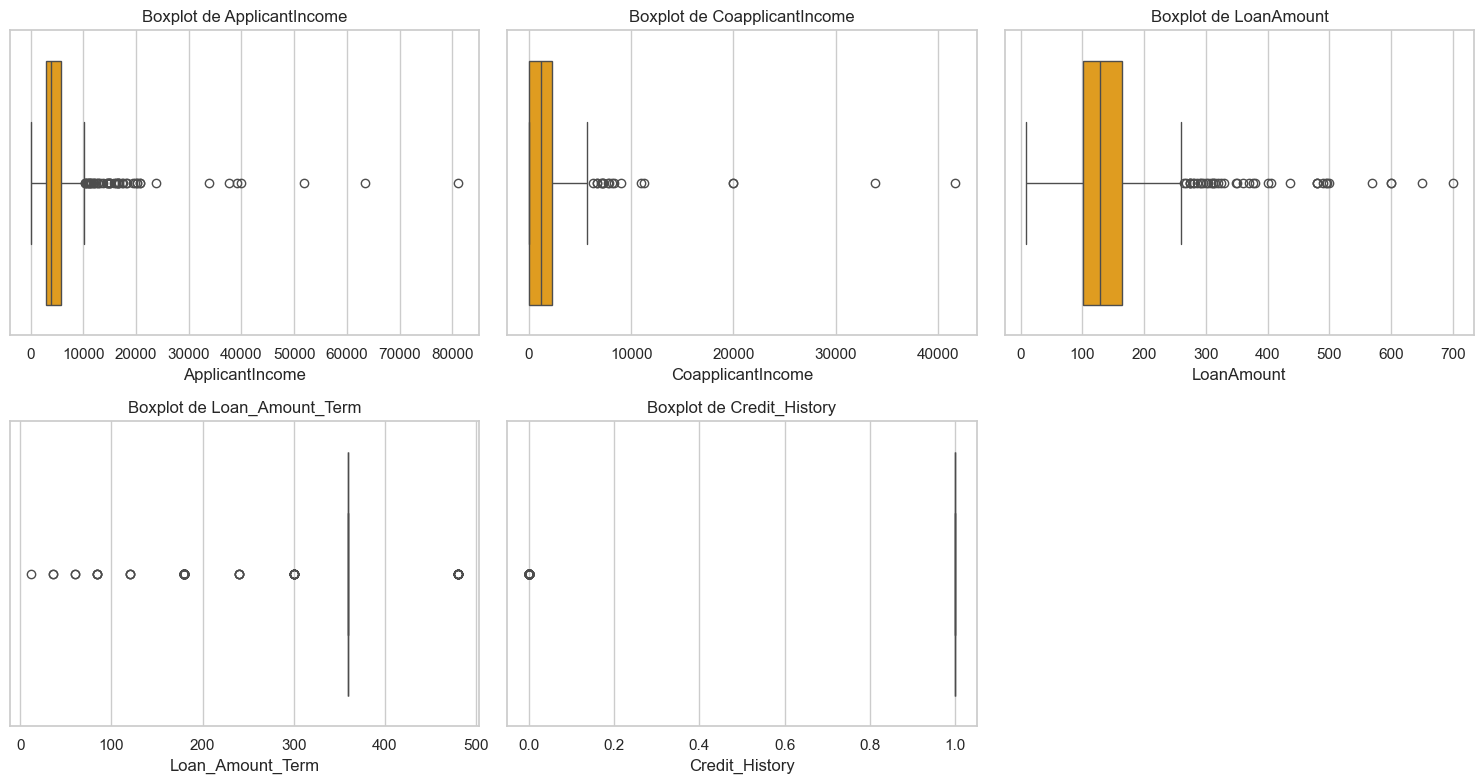

In [139]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

# Observations

ApplicantIncome et LoanAmount ont des outliers très marqués.

Des valeurs > 50k pour les revenus et > 500 pour les montants de prêt.

Les médianes sont bien centrées mais la distribution est asymétrique (skewed à droite).

Loan_Amount_Term : très concentré autour de 360 mois >> valeur dominante.

3. Heatmap des corrélations

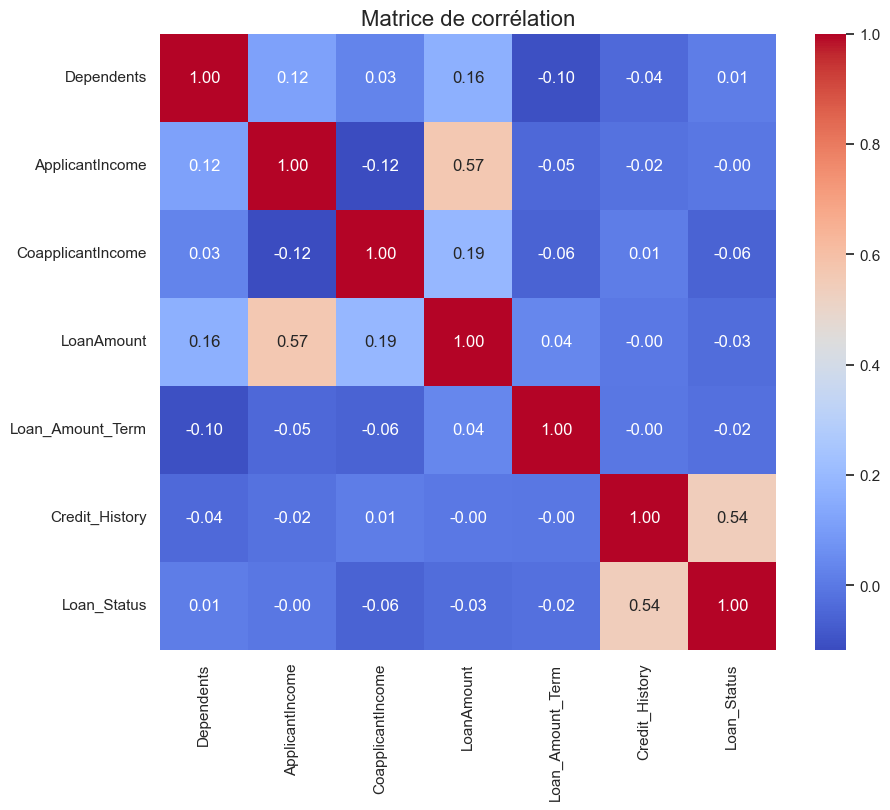

In [140]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation", fontsize=16)
plt.show()

# Observations

ApplicantIncome vs LoanAmount : r = 0.57 >> corrélation modérée, logique : plus le revenu principal est élevé, plus le prêt peut être important. A surveiller

CoapplicantIncome faiblement corrélé à tout >> probablement peu discriminant seul.

Credit_History quasi indépendante des autres variables numériques.

Les autres corrélations sont très faibles voire nulles.


4. Répartition de la variable cible Loan_Status

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_63942/1918455478.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


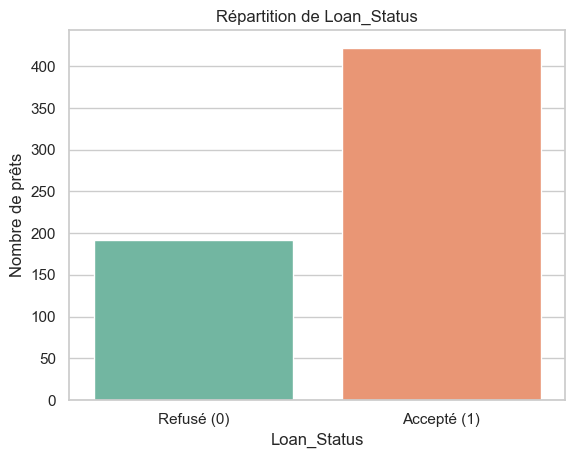

In [141]:
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Répartition de Loan_Status')
plt.xticks([0, 1], ['Refusé (0)', 'Accepté (1)'])
plt.ylabel('Nombre de prêts')
plt.show()

# Observations

69% acceptés vs 32% refusés

5. Influence du revenu vs approbation du prêt

In [142]:
print(df['Loan_Status'].unique())
print(df['Loan_Status'].value_counts())

[1 0]
Loan_Status
1    422
0    192
Name: count, dtype: int64


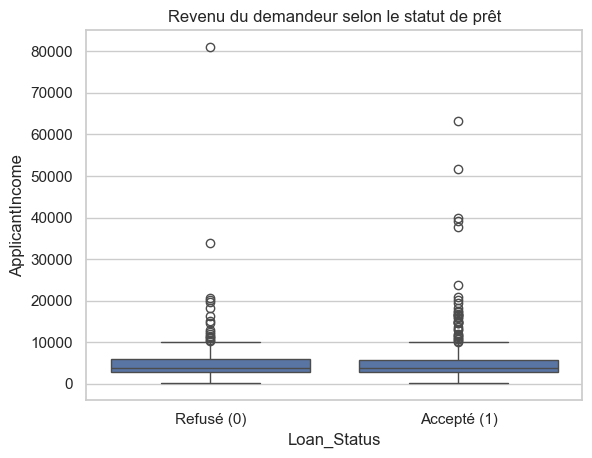

In [143]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Revenu du demandeur selon le statut de prêt")
plt.xticks([0, 1], ['Refusé (0)', 'Accepté (1)'])
plt.show()

# Observations

Les revenus moyens semblent légèrement plus élevés chez les prêts acceptés, mais la variance est énorme (outliers importants) >> le revenu n'est pas le seul critère décisif.

Étape 2 : Préparation des Données et Entraînement des Modèles

1. Sélection des features après EDA

* Conservées car pertinentes :

ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term : variables financières directes

Credit_History : très discriminante

Dependents : information sur charge de famille

Variables catégorielles transformées en dummies : Gender, Married, Education, Self_Employed, Property_Area

* Exclues :

Loan_ID : identifiant >> aucune valeur prédictive

Variables fortement corrélées entre elles

2. Préparation des données

In [144]:
# 5. Supprimer colonnes inutiles
df.drop(columns=['Loan_ID'], inplace=True, errors='ignore')

# 6. Encodage des variables catégorielles
df = pd.get_dummies(df, drop_first=True)

In [145]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.0,5849,0.0,128.0,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True
1,1.0,4583,1508.0,128.0,360.0,1.0,0,False,True,False,True,True,False,True,False,True,False,False
2,0.0,3000,0.0,66.0,360.0,1.0,1,False,True,False,True,True,False,False,True,False,False,True
3,0.0,2583,2358.0,120.0,360.0,1.0,1,False,True,False,True,False,True,True,False,False,False,True
4,0.0,6000,0.0,141.0,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True


In [146]:
# 7. Séparation features / cible
X = df.drop(columns='Loan_Status')
y = df['Loan_Status']

In [147]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.0,5849,0.0,128.0,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True
1,1.0,4583,1508.0,128.0,360.0,1.0,0,False,True,False,True,True,False,True,False,True,False,False
2,0.0,3000,0.0,66.0,360.0,1.0,1,False,True,False,True,True,False,False,True,False,False,True
3,0.0,2583,2358.0,120.0,360.0,1.0,1,False,True,False,True,False,True,True,False,False,False,True
4,0.0,6000,0.0,141.0,360.0,1.0,1,False,True,True,False,True,False,True,False,False,False,True


In [148]:
df = df.dropna(subset=['Loan_Status'])  # si pas encore fait
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # conversion si pas encore fait

X = df.drop(columns='Loan_Status')
y = df['Loan_Status']
print(X)
print(y)
print(y.isnull().sum())  # doit afficher 0

# Ensuite, on peut splitter en toute sécurité :
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

     Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0           0.0             5849                0.0       128.0   
1           1.0             4583             1508.0       128.0   
2           0.0             3000                0.0        66.0   
3           0.0             2583             2358.0       120.0   
4           0.0             6000                0.0       141.0   
..          ...              ...                ...         ...   
609         0.0             2900                0.0        71.0   
610         3.0             4106                0.0        40.0   
611         1.0             8072              240.0       253.0   
612         2.0             7583                0.0       187.0   
613         0.0             4583                0.0       133.0   

     Loan_Amount_Term  Credit_History  Gender_Female  Gender_Male  Married_No  \
0               360.0             1.0          False         True        True   
1               360.0            

In [149]:
df.isna().sum()  # Vérification finale des valeurs manquantes

Dependents                   0
ApplicantIncome              0
CoapplicantIncome            0
LoanAmount                   0
Loan_Amount_Term             0
Credit_History               0
Loan_Status                614
Gender_Female                0
Gender_Male                  0
Married_No                   0
Married_Yes                  0
Education_Graduate           0
Education_Not Graduate       0
Self_Employed_No             0
Self_Employed_Yes            0
Property_Area_Rural          0
Property_Area_Semiurban      0
Property_Area_Urban          0
dtype: int64

In [58]:
df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'].fillna(df['Credit_History'].mode()[0])

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

In [59]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [61]:
# 1. Remplir les NaN par la valeur la plus fréquente (mode)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

# 2. Remplacer '3+' par 3
df['Dependents'] = df['Dependents'].replace('3+', 3)

# 3. Convertir en int
df['Dependents'] = df['Dependents'].astype(int)

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_53935/1428184247.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


In [151]:
# Fonction pour supprimer les outliers par IQR

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Colonnes numériques à nettoyer
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    df = remove_outliers_iqr(df, col)

In [152]:
# Nettoyer et convertir 'Dependents'
# --------------------------------------
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

In [153]:
# Supprimer ou imputer les NaN restants

df = df.dropna()

In [154]:
# Encodage One-Hot des variables catégorielles

df = pd.get_dummies(df, drop_first=True)

In [155]:
# Séparer les features et la target

y = df['Loan_Status']
X = df.drop(columns=['Loan_Status'])

In [160]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")

# Affichage rapide
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [161]:
# Supprimer 'Loan_ID' (identifiant inutile)
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)

# Imputation des valeurs manquantes
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# Conversion de 'Loan_Status' en binaire
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

# Traitement de 'Dependents'
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_63942/288016672.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_63942/288016672.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [162]:
# One-hot encoding (on évite le piège des colonnes parfaitement corrélées avec drop_first)
df = pd.get_dummies(df, drop_first=True)

In [163]:
from scipy import stats

# On garde toutes les colonnes numériques sauf la target
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('Loan_Status')

# Calcul des z-scores
z_scores = stats.zscore(df[numerical_cols])

# Filtrage
df = df[(abs(z_scores) < 3).all(axis=1)]

print("Taille après suppression des outliers :", df.shape)

Taille après suppression des outliers : (577, 13)


In [164]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [165]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "Forêt Aléatoire": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Modèle": name,
        "Exactitude": round(accuracy_score(y_test, y_pred), 3),
        "Précision": round(precision_score(y_test, y_pred), 3),
        "Rappel": round(recall_score(y_test, y_pred), 3),
        "F1-score": round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

                  Modèle  Exactitude  Précision  Rappel  F1-score
0  Régression Logistique       0.819      0.811   0.963     0.880
1        Forêt Aléatoire       0.793      0.811   0.912     0.859


/Users/teddan/Desktop/GenAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [166]:
# Entraînement des modèles
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "Forêt Aléatoire": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Modèle": name,
        "Exactitude": round(accuracy_score(y_test, y_pred), 3),
        "Précision": round(precision_score(y_test, y_pred), 3),
        "Rappel": round(recall_score(y_test, y_pred), 3),
        "F1-score": round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)
print("\n🎯 Résultats des modèles :\n")
print(results_df)


🎯 Résultats des modèles :

                  Modèle  Exactitude  Précision  Rappel  F1-score
0  Régression Logistique       0.819      0.811   0.963     0.880
1        Forêt Aléatoire       0.793      0.811   0.912     0.859


/Users/teddan/Desktop/GenAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Observations

Exactitude (Accuracy) : proportion de bonnes prédictions globalement.

Précision (Precision) : parmi les prêts prédits comme "acceptés", combien le sont vraiment ?

Rappel (Recall) : parmi les prêts vraiment "acceptés", combien ont été bien prédits ?

F1-score : moyenne harmonique entre précision et rappel (plus équilibrée).